<a href="https://colab.research.google.com/github/likhith040/likhithsrao/blob/main/ml_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{\r\n  "username": "likhith",\r\n  "key": "KGAT_87999527652439f194db197f09845164"\r\n}                          '}

In [ ]:
import os
import shutil

# Create Kaggle directory
os.makedirs('/root/.kaggle', exist_ok=True)

# Move kaggle.json
shutil.move('kaggle.json', '/root/.kaggle/kaggle.json')

# Set permission
os.chmod('/root/.kaggle/kaggle.json', 0o600)

In [ ]:
!pip install kaggle

In [ ]:
!kaggle datasets download -d abhishek14398/salary-dataset-simple-linear-regression

Dataset URL: https://www.kaggle.com/datasets/abhishek14398/salary-dataset-simple-linear-regression
License(s): CC0-1.0
100% 457/457 [00:00<00:00, 1.29MB/s]



In [ ]:
import zipfile
import os
import pandas as pd

# Extract ZIP
with zipfile.ZipFile('salary-dataset-simple-linear-regression.zip', 'r') as zip_ref:
    zip_ref.extractall('data')

# 🔍 Find CSV file automatically
csv_path = None
for root, dirs, files in os.walk('data'):
    for file in files:
        if file.endswith('.csv'):
            csv_path = os.path.join(root, file)

print("CSV found at:", csv_path)

# 📂 Load dataset
df = pd.read_csv(csv_path)

# 👀 Preview
print(df.head())
print(df.info())

CSV found at: data/Salary_dataset.csv
   Unnamed: 0  YearsExperience   Salary
0           0              1.2  39344.0
1           1              1.4  46206.0
2           2              1.6  37732.0
3           3              2.1  43526.0
4           4              2.3  39892.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes
None


In [ ]:
df.describe()

,Unnamed: 0,YearsExperience,Salary
count,30.000000,30.000000,30.000000
mean,14.500000,5.413333,76004.000000
std,8.803408,2.837888,27414.429785
min,0.000000,1.200000,37732.000000
25%,7.250000,3.300000,56721.750000
50%,14.500000,4.800000,65238.000000
75%,21.750000,7.800000,100545.750000
max,29.000000,10.600000,122392.000000


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
YearsExperience,0
Salary,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)
print(df.drop_duplicates().sum())

Unnamed: 0             435.0
YearsExperience        162.4
Salary             2280120.0
dtype: float64


In [ ]:
df.columns

Index(['Unnamed: 0', 'YearsExperience', 'Salary'], dtype='object')

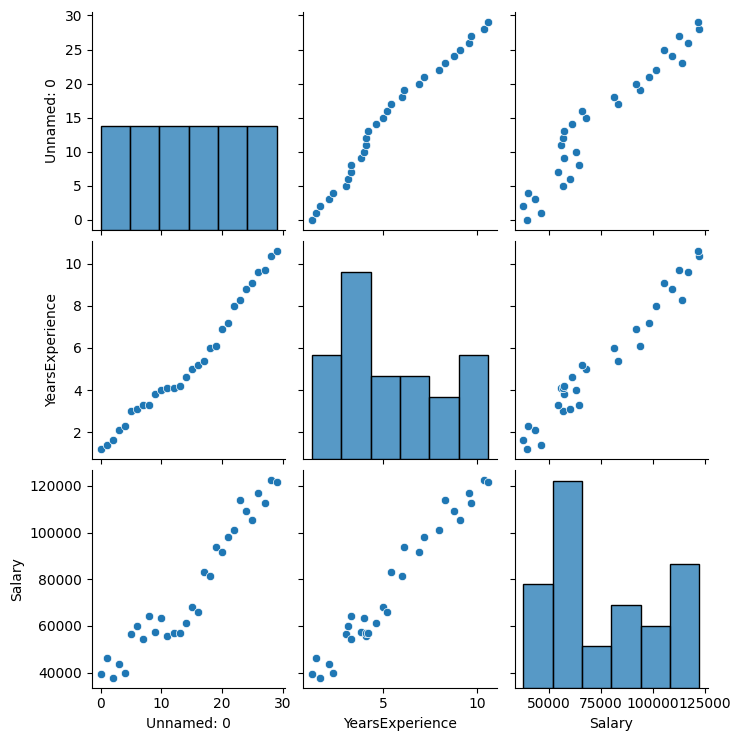

In [ ]:
sns.pairplot(df)
plt.show()

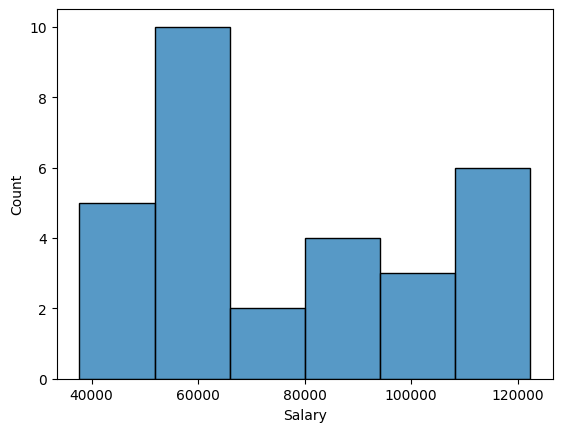

In [ ]:
sns.histplot(df['Salary'])
plt.show()

In [ ]:
!kaggle datasets download -d abhishek14398/salary-dataset-simple-linear-regression

Dataset URL: https://www.kaggle.com/datasets/abhishek14398/salary-dataset-simple-linear-regression
License(s): CC0-1.0
salary-dataset-simple-linear-regression.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
#Feature Engineering
df['Experience_Squared'] = df['YearsExperience'] ** 2
df.head()

,Unnamed: 0,YearsExperience,Salary,Experience_Squared
0,0,1.2,39344.0,1.44
1,1,1.4,46206.0,1.96
2,2,1.6,37732.0,2.56
3,3,2.1,43526.0,4.41
4,4,2.3,39892.0,5.29


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
import zipfile
import os
import pandas as pd

# Extract ZIP
with zipfile.ZipFile('salary-dataset-simple-linear-regression.zip', 'r') as zip_ref:
    zip_ref.extractall('data')

# 🔍 Find CSV file automatically
csv_path = None
for root, dirs, files in os.walk('data'):
    for file in files:
        if file.endswith('.csv'):
            csv_path = os.path.join(root, file)

print("CSV found at:", csv_path)

# 📂 Load dataset
df = pd.read_csv(csv_path)

# 👀 Preview
print(df.head())
print(df.info())

CSV found at: data/Salary_dataset.csv
   Unnamed: 0  YearsExperience   Salary
0           0              1.2  39344.0
1           1              1.4  46206.0
2           2              1.6  37732.0
3           3              2.1  43526.0
4           4              2.3  39892.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes
None


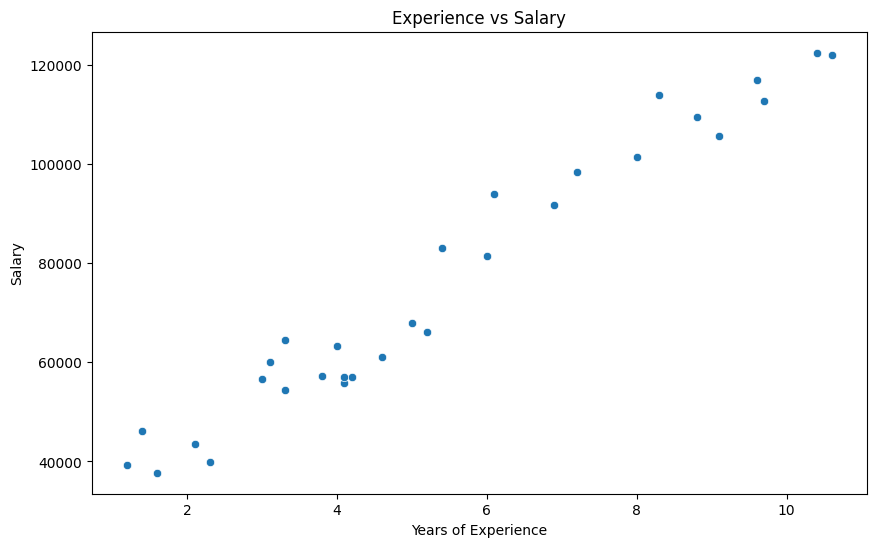

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='YearsExperience', y='Salary', data=df)
plt.title("Experience vs Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

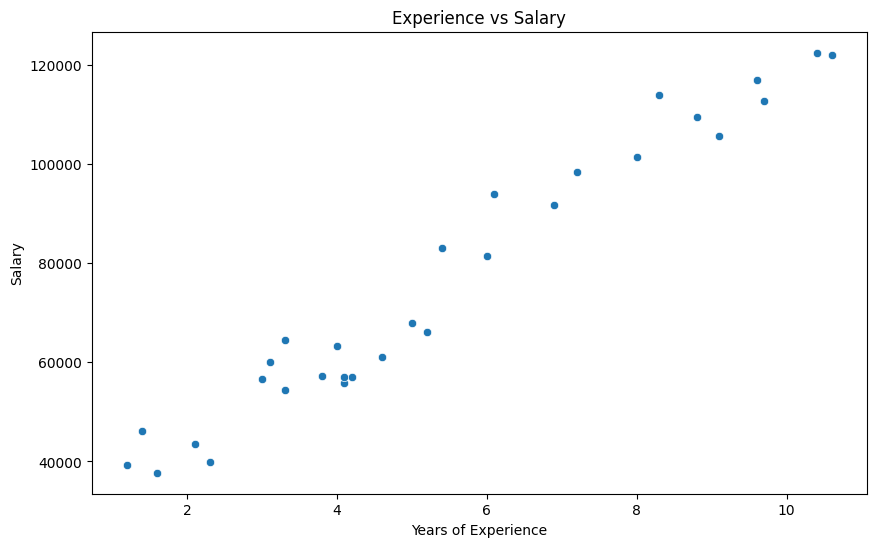

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='YearsExperience', y='Salary', data=df)
plt.title("Experience vs Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

In [ ]:
df['Experience_Squared'] = df['YearsExperience'] ** 2
X = df[['YearsExperience', 'Experience_Squared']]
y = df['Salary']
print(X)
print(y)

    YearsExperience  Experience_Squared
0               1.2                1.44
1               1.4                1.96
2               1.6                2.56
3               2.1                4.41
4               2.3                5.29
5               3.0                9.00
6               3.1                9.61
7               3.3               10.89
8               3.3               10.89
9               3.8               14.44
10              4.0               16.00
11              4.1               16.81
12              4.1               16.81
13              4.2               17.64
14              4.6               21.16
15              5.0               25.00
16              5.2               27.04
17              5.4               29.16
18              6.0               36.00
19              6.1               37.21
20              6.9               47.61
21              7.2               51.84
22              8.0               64.00
23              8.3               68.89
